# E-commerce Orders Analysis

Analyze order data with Python, pandas, Matplotlib, and SQLite to summarize delivered sales, monthly trends, product performance, and order statuses.

**Sales definition:** quantity × unit price, restricted to delivered orders. Currency is unspecified; sales value is not profit.

**How to run:** Place `ecommerce_dataset_10000.csv` beside this notebook, install the packages in `requirements.txt`, then restart the kernel and run all cells.

**Review note:** Existing results were retained from the original notebook. The edited notebook has not been rerun against the CSV, which was not provided during cleanup.

## 1. Load the Data

In [ ]:
from pathlib import Path
import sqlite3

import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
data_path = Path("ecommerce_dataset_10000.csv")
df = pd.read_csv(data_path)

In [ ]:
df.head()

,customer_id,first_name,last_name,gender,age_group,signup_date,country,product_id,product_name,category,quantity,unit_price,order_id,order_date,order_status,payment_method,rating,review_text,review_id,review_date
0,CUST2353,Erica,Oliver,Female,Teenagers,2022-06-29,Canada,PROD108,Fitbit Versa 3,Electronics,3,229,ORD10000,2023-07-13,Pending,Credit Card,2,good,REV20000,2025-06-06
1,CUST4463,Christopher,White,Male,Adults,2023-08-24,China,PROD103,Levi's Jeans,Apparel,4,59,ORD10001,2024-08-12,Pending,PayPal,2,average,REV20001,2023-08-05
2,CUST4512,Spencer,Foster,Male,Senior,2023-07-18,Germany,PROD111,Lego Star Wars Set,Toys,2,59,ORD10002,2024-08-04,Delivered,Cash on Delivery,5,good,REV20002,2023-01-03
3,CUST5711,Jessica,Harris,Male,Teenagers,2025-08-22,France,PROD107,Dyson Vacuum,Home & Kitchen,4,399,ORD10003,2025-05-23,Delivered,Cash on Delivery,2,very good,REV20003,2023-03-14
4,CUST1296,Amy,Johnson,Female,Teenagers,2021-03-23,Brazil,PROD105,Adidas Running Shoes,Apparel,1,110,ORD10004,2023-07-02,Returned,Cash on Delivery,1,very good,REV20004,2023-10-18


## 2. Data Quality and Date Preparation

Check missing values, exact duplicate rows, and unique order IDs before analysis. The saved results show 10,000 unique orders across 10,000 rows, no missing values, and no duplicate rows; no row removal was needed.

In [ ]:
print("rows and columns:", df.shape)
print("\ncolumn types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nOrder status:")
print(df["order_status"].value_counts(dropna=False))

print ("\nUnique orders:", df["order_id"].nunique())

rows and columns: (10000, 20)

column types:
customer_id       object
first_name        object
last_name         object
gender            object
age_group         object
signup_date       object
country           object
product_id        object
product_name      object
category          object
quantity           int64
unit_price         int64
order_id          object
order_date        object
order_status      object
payment_method    object
rating             int64
review_text       object
review_id         object
review_date       object
dtype: object

Missing values:
customer_id       0
first_name        0
last_name         0
gender            0
age_group         0
signup_date       0
country           0
product_id        0
product_name      0
category          0
quantity          0
unit_price        0
order_id          0
order_date        0
order_status      0
payment_method    0
rating            0
review_text       0
review_id         0
review_date       0
dtype: int64

Duplicate 

In [ ]:
for column in ["signup_date", "order_date", "review_date"]:
    df[column] = pd.to_datetime(df[column], errors="coerce")

# Prevent invalid dates from being silently excluded from monthly analysis.
assert df["order_date"].notna().all(), "Review invalid or missing order dates."
assert df["order_id"].notna().all(), "Review missing order IDs."
assert df["order_id"].is_unique, "Review repeated order IDs before interpreting order counts."

## 3. Delivered Sales Summary

Average order value is calculated by summing each delivered order first, then averaging across orders.

In [ ]:
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

# Calculate order value
df["order_value"] = df["quantity"] * df["unit_price"]

# Use delivered orders for completed-sales analysis
delivered = df[df["order_status"] == "Delivered"].copy()
print("Invalid or missing order dates:", df["order_date"].isna().sum())
print("Delivered orders:", delivered["order_id"].nunique())
print("Delivered sales value:",round(delivered["order_value"].sum(), 2))
print("Average delivered order value:", round(
    delivered.groupby("order_id")["order_value"].sum().mean(), 2
))
delivered[
    ["order_id", "quantity", "unit_price", "order_value"]
    ].head()

Invalid or missing order dates: 0
Delivered orders: 2037
Delivered sales value: 1582371
Average delivered order value: 776.81


,order_id,quantity,unit_price,order_value
2,ORD10002,2,59,118
3,ORD10003,4,399,1596
13,ORD10013,2,999,1998
17,ORD10017,2,149,298
18,ORD10018,1,80,80


## 4. Sales by Category, Product, Payment Method, and Country

The `revenue` column below is an alias for `order_value`, retained for the original pandas and SQL analyses. It represents delivered sales value, not accounting revenue or profit.

In [ ]:
df["revenue"] = df["order_value"]
delivered_orders = df.loc[df["order_status"] == "Delivered"].copy()

### Category Sales

In [ ]:
delivered_orders.groupby("category")["revenue"].sum().sort_values(ascending=False)

category
Electronics       1002864
Home & Kitchen     220863
Apparel            114955
Toys                98651
Books               78722
Sports              66316
Name: revenue, dtype: int64

### Product Sales and Units

In [ ]:
delivered_orders.groupby("product_name").agg({
    "quantity": "sum",
    "revenue": "sum",
}).sort_values("revenue", ascending = False)

,quantity,revenue
product_name,,
Samsung Galaxy S23,476,427924
iPhone 14,380,379620
Dyson Vacuum,460,183540
Sony Headphones,512,101888
Fitbit Versa 3,408,93432
Barbie Dreamhouse,389,77411
Wilson Tennis Racket,384,57216
Nike Air Max,382,45840
Kindle Paperwhite,338,43602


### Payment Methods

Order counts and sales totals by payment method.

In [ ]:
delivered_orders["payment_method"].value_counts()

payment_method
Cash on Delivery    701
PayPal              677
Credit Card         659
Name: count, dtype: int64

In [ ]:
delivered_orders.groupby("payment_method")["revenue"].sum()

payment_method
Cash on Delivery    477722
Credit Card         572211
PayPal              532438
Name: revenue, dtype: int64

### Country Sales

Delivered sales totals and order counts by country.

In [ ]:
delivered_orders.groupby("country")["revenue"].sum().sort_values(ascending=False)

country
France       196834
Japan        187525
USA          168554
Brazil       160287
Canada       159443
Germany      158035
UK           148864
China        146588
Australia    141801
India        114440
Name: revenue, dtype: int64

In [ ]:
delivered_orders["country"].value_counts()

country
Brazil       220
France       218
China        218
Canada       216
Germany      206
Japan        202
USA          199
UK           199
Australia    187
India        172
Name: count, dtype: int64

## 5. Monthly Delivered Sales

The first and last months have partial date coverage and should not be directly compared with full months.

order_date
2022-08    15058
2022-09    37221
2022-10    29703
2022-11    43100
2022-12    31627
2023-01    47075
2023-02    31802
2023-03    32721
2023-04    37575
2023-05    50503
2023-06    41287
2023-07    33337
2023-08    47748
2023-09    43706
2023-10    43524
2023-11    49571
2023-12    35684
2024-01    32283
2024-02    47925
2024-03    41480
2024-04    37446
2024-05    56386
2024-06    44276
2024-07    52055
2024-08    73792
2024-09    46306
2024-10    48682
2024-11    47201
2024-12    27510
2025-01    50911
2025-02    44389
2025-03    59285
2025-04    49823
2025-05    35967
2025-06    55314
2025-07    49482
2025-08    30616
Freq: M, Name: order_value, dtype: int64


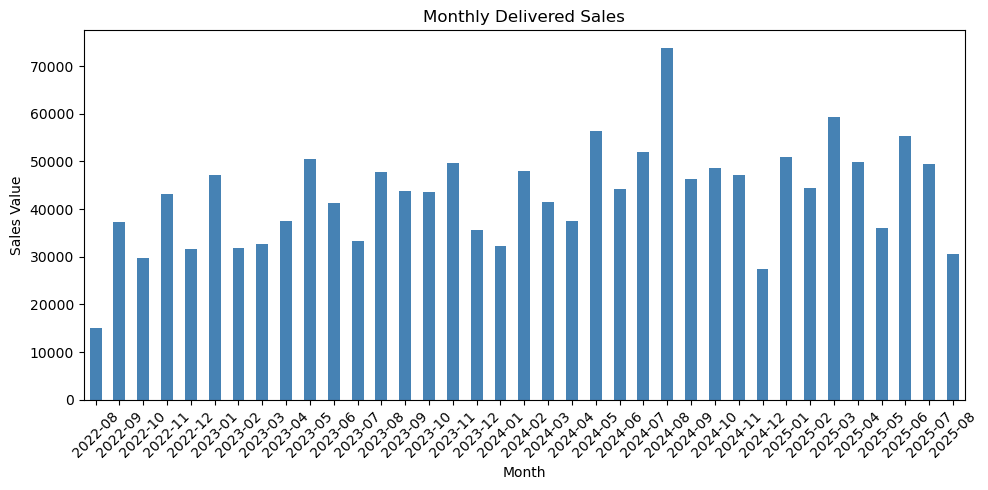

In [ ]:
# Group delivered sales by month
monthly_sales = (
    delivered.groupby(delivered["order_date"].dt.to_period("M"))["order_value"]
    .sum()
    .sort_index()
)
print(monthly_sales)

# Plot monthly sales

monthly_sales.plot(kind="bar", figsize=(10, 5), color="steelblue")

plt.title("Monthly Delivered Sales")
plt.xlabel("Month")
plt.ylabel("Sales Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
print("Highest sales month:", monthly_sales.idxmax())
print("Highest monthly sales:", monthly_sales.max())

print("Lowest sales month:", monthly_sales.idxmin())
print("Lowest monthly sales:", monthly_sales.min())

#Check the dataset's date coverage
print("First order date:", df["order_date"].min())
print("Last order date:", df["order_date"].max())

Highest sales month: 2024-08
Highest monthly sales: 73792
Lowest sales month: 2022-08
Lowest monthly sales: 15058
First order date: 2022-08-25 00:00:00
Last order date: 2025-08-24 00:00:00


## 6. Order Status Breakdown

Count unique order IDs within each status.

order_status
Shipped      2063
Delivered    2037
Cancelled    1970
Pending      1968
Returned     1962
Name: order_id, dtype: int64


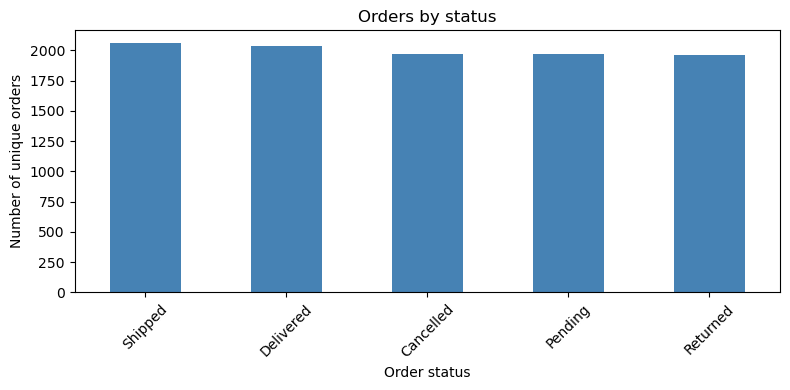

In [ ]:
# Count unique orders in each status
status_counts = (
    df.groupby("order_status")["order_id"]
    .nunique()
    .sort_values(ascending=False)
)

print(status_counts)

status_counts.plot(kind="bar", figsize=(8, 4), color="steelblue")
plt.title("Orders by status")
plt.xlabel("Order status")
plt.ylabel("Number of unique orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. SQL Analysis

Use a temporary SQLite database to express selected analyses in SQL. It is rebuilt each run and does not require a database file or credentials.

In [ ]:
conn = sqlite3.connect(":memory:")
df.to_sql("orders", conn, if_exists="replace", index=False);

### Delivered Sales by Category

In [ ]:
query = """
SELECT category, SUM(revenue) AS total_revenue
FROM orders
WHERE order_status = 'Delivered'
GROUP by category
ORDER BY total_revenue DESC;
"""

pd.read_sql_query(query, conn)

,category,total_revenue
0,Electronics,1002864
1,Home & Kitchen,220863
2,Apparel,114955
3,Toys,98651
4,Books,78722
5,Sports,66316


### Total Delivered Sales

In [ ]:
query = """
SELECT SUM(revenue) As delivered_revenue
FROM orders
WHERE order_status = 'Delivered'
"""

pd.read_sql_query(query, conn)

,delivered_revenue
0,1582371


### Top 10 Products by Delivered Sales

In [ ]:
query = """
SELECT product_name, SUM(revenue) AS total_revenue
FROM orders
WHERE order_status = 'Delivered'
GROUP BY product_name
ORDER BY total_revenue DESC
LIMIT 10;
"""

pd.read_sql_query(query, conn)

,product_name,total_revenue
0,Samsung Galaxy S23,427924
1,iPhone 14,379620
2,Dyson Vacuum,183540
3,Sony Headphones,101888
4,Fitbit Versa 3,93432
5,Barbie Dreamhouse,77411
6,Wilson Tennis Racket,57216
7,Nike Air Max,45840
8,Kindle Paperwhite,43602
9,Adidas Running Shoes,43450


### Monthly Delivered Sales

In [ ]:
query = """
SELECT strftime('%Y-%m', order_date) AS month,
       SUM(revenue) AS total_revenue
FROM orders
WHERE order_status = 'Delivered'
GROUP BY month
ORDER By month;
"""

pd.read_sql_query(query, conn)

,month,total_revenue
0,2022-08,15058
1,2022-09,37221
2,2022-10,29703
3,2022-11,43100
4,2022-12,31627
5,2023-01,47075
6,2023-02,31802
7,2023-03,32721
8,2023-04,37575
9,2023-05,50503


In [ ]:
conn.close()

## 8. Conclusion

### Key Findings

- Delivered orders totaled 2,037, with a combined sales value
  of 1,582,371 and an average order value of 776.81.
- August 2024 had the highest delivered sales at 73,792.
- August 2022 had the lowest recorded sales at 15,058.
  However, coverage begins on August 25, making it a partial month.
  August 2025 is also incomplete, ending on August 24.
- Order statuses were fairly evenly distributed: Shipped (2,063),
  Delivered (2,037), Cancelled (1,970), Pending (1,968),
  and Returned (1,962).
- No missing or invalid order dates were found after date conversion.

### Limitations

Sales value is calculated as quantity × unit price for delivered
orders only. It does not represent profit or account for discounts,
taxes, or shipping charges. The currency has not been confirmed.
Partial months should not be directly compared with full months.

Dataset source and license should be documented before redistributing the CSV. The analysis describes this dataset and does not establish causes for sales changes.